In [1]:
!pip -q install transformers

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
!pip install --user scipy==1.14.1 numpy==1.26.4 --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 222.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 196.2 MB/s  0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]32m1/2 [scipy]


In [3]:
!pip -q install transformer_lens

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [4]:
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124 -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformer-lens 2.17.0 requires torch>=2.6; python_version >= "3.9", but you have torch 2.5.1+cu124 which is incompatible.


In [5]:
!pip -q install equiadapt

In [6]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 145.1 MB/s  0:00:00


In [1]:
# Cell 1: Imports and Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
from typing import Tuple, Optional, Dict, List
from dataclasses import dataclass, field
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, Subset
import warnings
warnings.filterwarnings('ignore')

# E2-CNN imports
from escnn import gspaces
from escnn import nn as e2nn

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cuda


In [2]:
# Cell 2: Configuration Dataclass
@dataclass
class EquivariantPINNConfig:
    """Configuration for Physics-Informed Equivariant Network"""
    
    # Image settings
    img_size: int = 150  # Your dataset is 150x150
    in_channels: int = 1
    num_classes: int = 3
    
    # Physics parameters
    pixel_scale: float = 0.101  # arcsec/pixel
    min_angle: float = -3.232
    max_angle: float = 3.232
    einstein_radius_range: Tuple[float, float] = (0.5, 2.0)
    
    # E2-CNN settings
    rotation_order: int = 8  # C8 symmetry
    
    # Feature dimensions
    image_features: int = 256
    physics_features: int = 128
    source_features: int = 128
    fused_features: int = 512
    
    # Training
    dropout: float = 0.2
    batch_size: int = 32
    learning_rate: float = 1e-4
    num_epochs: int = 30
    weight_decay: float = 1e-5
    
    device: str = field(default_factory=lambda: "cuda" if torch.cuda.is_available() else "cpu")

# Create config
config = EquivariantPINNConfig()
print(f"Configuration created: {config}")

Configuration created: EquivariantPINNConfig(img_size=150, in_channels=1, num_classes=3, pixel_scale=0.101, min_angle=-3.232, max_angle=3.232, einstein_radius_range=(0.5, 2.0), rotation_order=8, image_features=256, physics_features=128, source_features=128, fused_features=512, dropout=0.2, batch_size=32, learning_rate=0.0001, num_epochs=30, weight_decay=1e-05, device='cuda')


In [3]:
# Cell 3 (Part 1): Physics-Aware Data Augmentation
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import random

class PhysicsAwareAugmentation:
    """
    Physics-aware augmentation for gravitational lensing images.
    Preserves lensing physics while adding realistic variations.
    """
    
    def __init__(self, 
                 rotation_prob: float = 0.5,
                 flip_prob: float = 0.5,
                 brightness_range: Tuple[float, float] = (0.9, 1.1),
                 contrast_range: Tuple[float, float] = (0.9, 1.1),
                 noise_std: float = 0.02,
                 translate_range: float = 0.05,  # Max 5% translation
                 training: bool = True):
        """
        Args:
            rotation_prob: Probability of random rotation
            flip_prob: Probability of horizontal/vertical flip
            brightness_range: Range for brightness adjustment
            contrast_range: Range for contrast adjustment
            noise_std: Standard deviation of Gaussian noise
            translate_range: Max translation as fraction of image size
            training: Whether in training mode (augmentation only during training)
        """
        self.rotation_prob = rotation_prob
        self.flip_prob = flip_prob
        self.brightness_range = brightness_range
        self.contrast_range = contrast_range
        self.noise_std = noise_std
        self.translate_range = translate_range
        self.training = training
    
    def __call__(self, image: torch.Tensor) -> torch.Tensor:
        """
        Apply augmentations to image.
        
        Args:
            image: [C, H, W] tensor
            
        Returns:
            Augmented image tensor
        """
        if not self.training:
            return image
        
        # Random rotation (0, 90, 180, 270 degrees for exact equivariance)
        if random.random() < self.rotation_prob:
            k = random.randint(0, 3)  # Number of 90-degree rotations
            image = torch.rot90(image, k, dims=[1, 2])
        
        # Continuous random rotation (small angles)
        if random.random() < self.rotation_prob * 0.5:
            angle = random.uniform(-15, 15)  # Small angle rotation
            image = TF.rotate(image, angle, fill=0)
        
        # Random horizontal flip
        if random.random() < self.flip_prob:
            image = TF.hflip(image)
        
        # Random vertical flip
        if random.random() < self.flip_prob:
            image = TF.vflip(image)
        
        # Random brightness adjustment
        brightness_factor = random.uniform(*self.brightness_range)
        image = image * brightness_factor
        
        # Random contrast adjustment
        contrast_factor = random.uniform(*self.contrast_range)
        mean = image.mean()
        image = (image - mean) * contrast_factor + mean
        
        # Add Gaussian noise
        if self.noise_std > 0:
            noise = torch.randn_like(image) * self.noise_std
            image = image + noise
        
        # Small random translation (keeps lens roughly centered)
        if self.translate_range > 0 and random.random() < 0.3:
            _, h, w = image.shape
            max_dx = int(w * self.translate_range)
            max_dy = int(h * self.translate_range)
            dx = random.randint(-max_dx, max_dx)
            dy = random.randint(-max_dy, max_dy)
            image = TF.affine(image, angle=0, translate=(dx, dy), scale=1.0, shear=0)
        
        # Clamp to valid range
        image = image.clamp(0, 1)
        
        return image

# Test augmentation
print("Testing Physics-Aware Augmentation...")
aug = PhysicsAwareAugmentation(training=True)
test_img = torch.rand(1, 150, 150)
aug_img = aug(test_img)
print(f"Original shape: {test_img.shape}, Augmented shape: {aug_img.shape}")
print(f"Original range: [{test_img.min():.3f}, {test_img.max():.3f}]")
print(f"Augmented range: [{aug_img.min():.3f}, {aug_img.max():.3f}]")

Testing Physics-Aware Augmentation...
Original shape: torch.Size([1, 150, 150]), Augmented shape: torch.Size([1, 150, 150])
Original range: [0.000, 1.000]
Augmented range: [0.000, 1.000]


In [4]:
# Cell 3: Dataset Class
class DarkMatterDataset(Dataset):
    """Dataset for Dark Matter Substructure Classification"""
    
    def __init__(self, data_dir: str, transform=None):
        """
        Args:
            data_dir: Path to directory containing class folders (no, sphere, vort)
            transform: Optional transform to apply
        """
        self.data_dir = data_dir
        self.transform = transform
        self.classes = ['no', 'sphere', 'vort']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        # Load all file paths
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(data_dir, class_name)
            if os.path.exists(class_dir):
                for file_name in os.listdir(class_dir):
                    if file_name.endswith('.npy'):
                        self.samples.append({
                            'path': os.path.join(class_dir, file_name),
                            'label': self.class_to_idx[class_name]
                        })
        
        print(f"Loaded {len(self.samples)} samples from {data_dir}")
        
        # Count per class
        class_counts = {cls: 0 for cls in self.classes}
        for sample in self.samples:
            class_counts[self.classes[sample['label']]] += 1
        print(f"Class distribution: {class_counts}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Load image
        image = np.load(sample['path']).astype(np.float32)
        
        # Ensure shape is (1, H, W)
        if image.ndim == 2:
            image = image[np.newaxis, ...]
        elif image.ndim == 3 and image.shape[0] != 1:
            image = image.transpose(2, 0, 1)[:1]  # Take first channel
        
        # Convert to tensor
        image = torch.from_numpy(image)
        
        # Normalize to [0, 1] if not already
        if image.max() > 1.0:
            image = image / image.max()
        
        if self.transform:
            image = self.transform(image)
        
        label = sample['label']
        
        return image, label

# Test dataset loading
train_dir = "/home/jovyan/work/dataset/dataset/train"
val_dir = "/home/jovyan/work/dataset/dataset/val"

train_dataset = DarkMatterDataset(train_dir)
val_dataset = DarkMatterDataset(val_dir)

# Check sample
sample_img, sample_label = train_dataset[0]
print(f"\nSample image shape: {sample_img.shape}")
print(f"Sample label: {sample_label} ({train_dataset.classes[sample_label]})")

Loaded 30000 samples from /home/jovyan/work/dataset/dataset/train
Class distribution: {'no': 10000, 'sphere': 10000, 'vort': 10000}
Loaded 7500 samples from /home/jovyan/work/dataset/dataset/val
Class distribution: {'no': 2500, 'sphere': 2500, 'vort': 2500}

Sample image shape: torch.Size([1, 150, 150])
Sample label: 0 (no)


In [5]:
# Cell 4: Create Data Loaders with 10% Test Split
from torch.utils.data import random_split

# Combine train and val datasets
full_train_dataset = train_dataset

# Split validation set: 90% for validation, 10% for test
val_indices = list(range(len(val_dataset)))
val_labels = [val_dataset.samples[i]['label'] for i in val_indices]

# Stratified split for test set
val_idx, test_idx = train_test_split(
    val_indices, 
    test_size=0.1,  # 10% of val for test
    stratify=val_labels,
    random_state=42
)

val_subset = Subset(val_dataset, val_idx)
test_subset = Subset(val_dataset, test_idx)

print(f"Training samples: {len(full_train_dataset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test_subset)}")

# Create DataLoaders
train_loader = DataLoader(
    full_train_dataset, 
    batch_size=config.batch_size, 
    shuffle=True, 
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_subset, 
    batch_size=config.batch_size, 
    shuffle=False, 
    num_workers=0
)

test_loader = DataLoader(
    test_subset, 
    batch_size=config.batch_size, 
    shuffle=False, 
    num_workers=0
)

# Verify loaders
for images, labels in train_loader:
    print(f"\nBatch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Labels: {labels[:8].tolist()}")
    break

Training samples: 30000
Validation samples: 6750
Test samples: 750

Batch shape: torch.Size([32, 1, 150, 150])
Labels shape: torch.Size([32])
Labels: [2, 2, 1, 1, 0, 1, 2, 2]


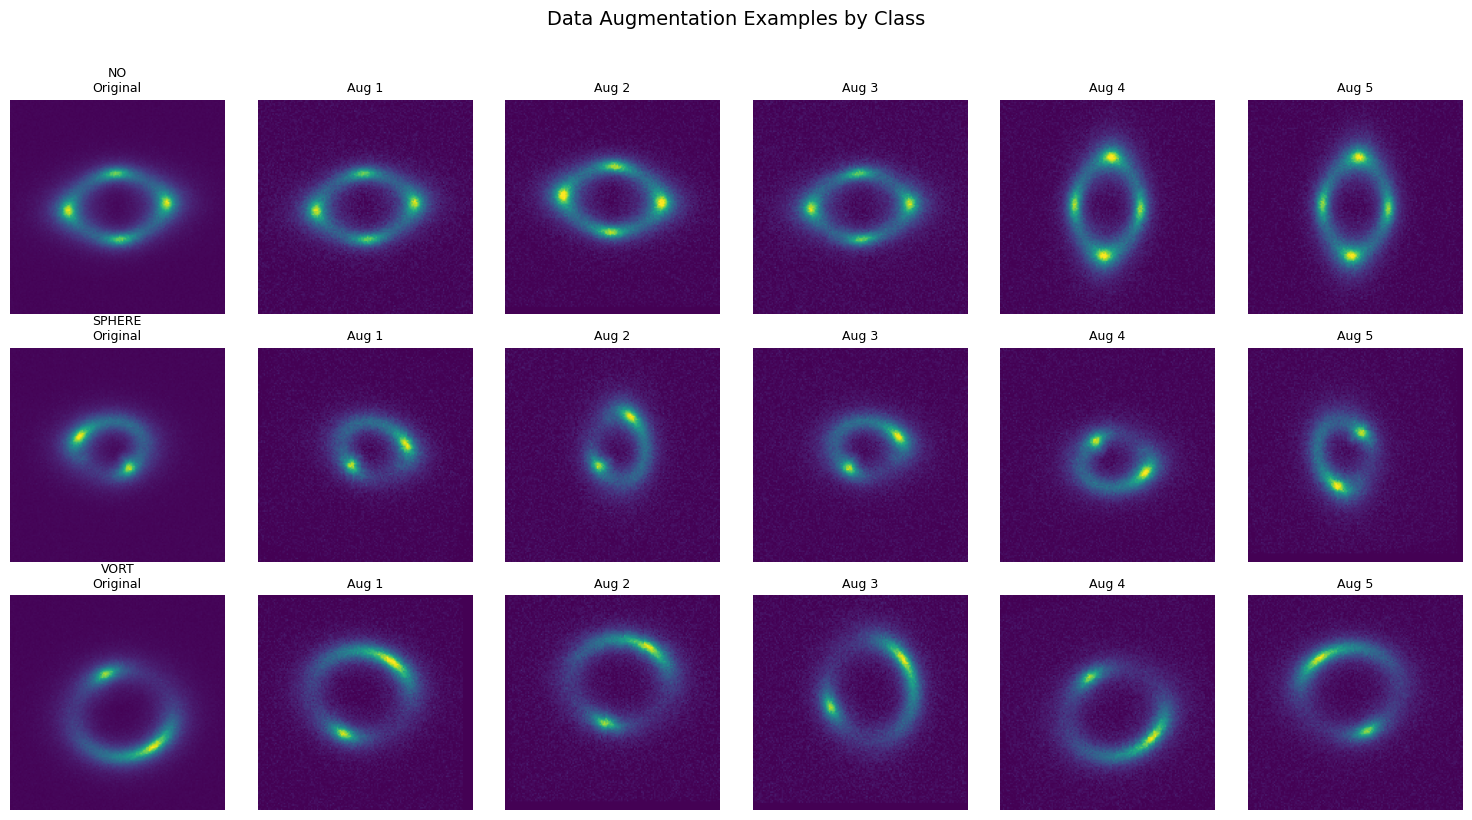

Augmentation examples saved to 'augmentation_examples.png'


In [6]:
# Cell 4.5: Visualize Augmentation Effects
fig, axes = plt.subplots(3, 6, figsize=(15, 8))

# Get a sample image
sample_idx = 100
original_img = np.load(train_dataset.samples[sample_idx]['path']).astype(np.float32)
if original_img.ndim == 2:
    original_img = original_img[np.newaxis, ...]
original_tensor = torch.from_numpy(original_img)

# Show original
axes[0, 0].imshow(original_tensor[0], cmap='viridis')
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

# Show augmented versions
aug = PhysicsAwareAugmentation(training=True)
for i in range(5):
    aug_img = aug(original_tensor.clone())
    axes[0, i+1].imshow(aug_img[0], cmap='viridis')
    axes[0, i+1].set_title(f'Aug {i+1}', fontsize=10)
    axes[0, i+1].axis('off')

# Show more samples from different classes
for row, class_name in enumerate(['no', 'sphere', 'vort']):
    class_dir = os.path.join(train_dir, class_name)
    files = [f for f in os.listdir(class_dir) if f.endswith('.npy')]
    sample_file = os.path.join(class_dir, files[50])
    
    img = np.load(sample_file).astype(np.float32)
    if img.ndim == 2:
        img = img[np.newaxis, ...]
    img_tensor = torch.from_numpy(img)
    
    # Original
    axes[row, 0].imshow(img_tensor[0], cmap='viridis')
    axes[row, 0].set_title(f'{class_name.upper()}\nOriginal', fontsize=9)
    axes[row, 0].axis('off')
    
    # Augmented
    for col in range(1, 6):
        aug_img = aug(img_tensor.clone())
        axes[row, col].imshow(aug_img[0], cmap='viridis')
        axes[row, col].set_title(f'Aug {col}', fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('Data Augmentation Examples by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Augmentation examples saved to 'augmentation_examples.png'")

In [7]:
# Cell 5: Gravitational Lensing Physics Module
class GravitationalLensingPhysics(nn.Module):
    """
    Computes gravitational lensing observables using SIS model.
    
    Outputs 5 physics channels:
    - κ (convergence): surface mass density
    - γ1, γ2 (shear): tidal gravitational field components
    - μ (magnification): flux amplification  
    - |α| (deflection): light bending angle magnitude
    """
    
    def __init__(self, img_size: int, pixel_scale: float = 0.101, 
                 min_angle: float = -3.232, max_angle: float = 3.232):
        super().__init__()
        
        self.img_size = img_size
        self.pixel_scale = pixel_scale
        
        # Create coordinate grid in angular units
        coords = torch.linspace(min_angle, max_angle, img_size)
        y, x = torch.meshgrid(coords, coords, indexing='ij')
        r = torch.sqrt(x**2 + y**2).clamp(min=1e-6)
        phi = torch.atan2(y, x)
        
        self.register_buffer('x', x)
        self.register_buffer('y', y)
        self.register_buffer('r', r)
        self.register_buffer('phi', phi)
        
        # Learnable Einstein radius predictor
        self.einstein_predictor = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
            nn.Linear(32 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Softplus()  # Ensures positive Einstein radius
        )
    
    def forward(self, images: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            images: [B, 1, H, W] input lensing images
            
        Returns:
            physics_features: [B, 5, H, W] - κ, γ1, γ2, μ, |α|
            einstein_radius: [B, 1] - predicted Einstein radius
        """
        B = images.shape[0]
        
        # Predict Einstein radius from image
        theta_E = self.einstein_predictor(images) + 0.5  # [B, 1], offset for stability
        
        # Expand grid tensors for batch
        r = self.r.unsqueeze(0).expand(B, -1, -1)
        phi = self.phi.unsqueeze(0).expand(B, -1, -1)
        theta_E_spatial = theta_E.view(B, 1, 1)
        
        # SIS Model Calculations:
        
        # Convergence: κ = θ_E / (2|θ|)
        kappa = theta_E_spatial / (2 * r)
        
        # Shear magnitude: |γ| = θ_E / (2|θ|) (same as κ for SIS)
        gamma_mag = theta_E_spatial / (2 * r)
        
        # Shear components (spin-2 field)
        gamma1 = gamma_mag * torch.cos(2 * phi)
        gamma2 = gamma_mag * torch.sin(2 * phi)
        
        # Magnification: μ = 1 / |det(A)| = 1 / |(1-κ)² - |γ|²|
        det_A = (1 - kappa)**2 - gamma_mag**2
        mu = 1.0 / det_A.abs().clamp(min=1e-4)
        mu = mu.clamp(max=100)  # Prevent extreme values
        
        # Deflection angle magnitude: |α| = θ_E (constant for SIS)
        alpha_mag = theta_E_spatial.expand(-1, self.img_size, self.img_size)
        
        # Normalize features for better training
        kappa_norm = torch.tanh(kappa)
        gamma1_norm = torch.tanh(gamma1)
        gamma2_norm = torch.tanh(gamma2)
        mu_norm = torch.log1p(mu) / 5.0  # Log-scale magnification
        alpha_norm = alpha_mag / 2.0  # Scale to ~[0, 1]
        
        # Stack physics channels: [B, 5, H, W]
        physics_features = torch.stack([
            kappa_norm, gamma1_norm, gamma2_norm, mu_norm, alpha_norm
        ], dim=1)
        
        return physics_features, theta_E

# Test physics module
physics = GravitationalLensingPhysics(img_size=150).to(device)
test_img = torch.randn(2, 1, 150, 150).to(device)
phys_feat, einstein_r = physics(test_img)
print(f"Physics features shape: {phys_feat.shape}")
print(f"Einstein radius shape: {einstein_r.shape}")

Physics features shape: torch.Size([2, 5, 150, 150])
Einstein radius shape: torch.Size([2, 1])


In [8]:
# Cell 6: Differentiable Source Reconstruction Module
class DifferentiableSourceReconstruction(nn.Module):
    """
    Reconstructs source image using differentiable ray-tracing.
    Uses grid_sample for fully differentiable reconstruction.
    """
    
    def __init__(self, img_size: int, min_angle: float = -3.232, max_angle: float = 3.232):
        super().__init__()
        
        self.img_size = img_size
        self.min_angle = min_angle
        self.max_angle = max_angle
        
        # Create normalized coordinate grid [-1, 1]
        coords = torch.linspace(-1, 1, img_size)
        grid_y, grid_x = torch.meshgrid(coords, coords, indexing='ij')
        
        # Angular coordinates
        ang_coords = torch.linspace(min_angle, max_angle, img_size)
        ang_y, ang_x = torch.meshgrid(ang_coords, ang_coords, indexing='ij')
        r = torch.sqrt(ang_x**2 + ang_y**2).clamp(min=1e-6)
        
        self.register_buffer('grid_x', grid_x)
        self.register_buffer('grid_y', grid_y)
        self.register_buffer('ang_x', ang_x)
        self.register_buffer('ang_y', ang_y)
        self.register_buffer('r', r)
    
    def forward(self, images: torch.Tensor, einstein_radius: torch.Tensor) -> torch.Tensor:
        """
        Args:
            images: [B, 1, H, W] observed lensing images
            einstein_radius: [B, 1] Einstein radius
            
        Returns:
            source: [B, 1, H, W] reconstructed source images
        """
        B = images.shape[0]
        
        # Compute deflection field (SIS model)
        theta_E = einstein_radius.view(B, 1, 1)
        
        # Deflection: α = θ_E * θ / |θ|
        alpha_x = theta_E * self.ang_x / self.r
        alpha_y = theta_E * self.ang_y / self.r
        
        # Source position: β = θ - α
        # Convert back to normalized coordinates
        scale = (self.max_angle - self.min_angle) / 2
        
        source_x = self.grid_x - alpha_x / scale
        source_y = self.grid_y - alpha_y / scale
        
        # Clamp to valid range
        source_x = source_x.clamp(-1, 1)
        source_y = source_y.clamp(-1, 1)
        
        # Create sampling grid [B, H, W, 2]
        grid = torch.stack([source_x, source_y], dim=-1)
        
        # Sample from image using grid_sample (fully differentiable)
        source = F.grid_sample(images, grid, mode='bilinear', 
                               padding_mode='zeros', align_corners=True)
        
        return source

# Test source reconstruction
source_recon = DifferentiableSourceReconstruction(img_size=150).to(device)
einstein_r_test = torch.tensor([[1.0], [1.5]]).to(device)
source_test = source_recon(test_img, einstein_r_test)
print(f"Source reconstruction shape: {source_test.shape}")

Source reconstruction shape: torch.Size([2, 1, 150, 150])


In [9]:
# Cell 7: E2-Equivariant Encoder
class E2EquivariantEncoder(nn.Module):
    """
    E(2)-Equivariant CNN encoder using steerable convolutions.
    Maintains rotation equivariance through C_N cyclic group.
    """
    
    def __init__(self, in_channels: int, out_features: int, 
                 n_rotations: int = 8, img_size: int = 150):
        super().__init__()
        
        self.img_size = img_size
        self.out_features = out_features
        
        # Define symmetry group: C_N discrete rotations
        self.r2_act = gspaces.rot2dOnR2(N=n_rotations)
        
        # Input: trivial representation (scalar field)
        in_type = e2nn.FieldType(self.r2_act, in_channels * [self.r2_act.trivial_repr])
        self.input_type = in_type
        
        # Build equivariant network
        self._build_network(in_type)
        
        # Output projection (lazy initialization)
        self._flat_size = None
        self.out_proj = None
    
    def _build_network(self, in_type):
        """Build the equivariant convolutional layers"""
        
        # Block 1: Input → 24 regular features
        out_type1 = e2nn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = e2nn.SequentialModule(
            e2nn.MaskModule(in_type, self.img_size, margin=1),
            e2nn.R2Conv(in_type, out_type1, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type1),
            e2nn.ReLU(out_type1, inplace=True)
        )
        
        # Block 2: 24 → 48 features + pool
        out_type2 = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = e2nn.SequentialModule(
            e2nn.R2Conv(out_type1, out_type2, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type2),
            e2nn.ReLU(out_type2, inplace=True)
        )
        self.pool1 = e2nn.PointwiseAvgPoolAntialiased(out_type2, sigma=0.66, stride=2)
        
        # Block 3: 48 → 48 features
        out_type3 = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = e2nn.SequentialModule(
            e2nn.R2Conv(out_type2, out_type3, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type3),
            e2nn.ReLU(out_type3, inplace=True)
        )
        
        # Block 4: 48 → 64 features + pool
        out_type4 = e2nn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block4 = e2nn.SequentialModule(
            e2nn.R2Conv(out_type3, out_type4, kernel_size=3, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type4),
            e2nn.ReLU(out_type4, inplace=True)
        )
        self.pool2 = e2nn.PointwiseAvgPoolAntialiased(out_type4, sigma=0.66, stride=2)
        
        # Block 5: 64 → 64 features + pool
        out_type5 = e2nn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block5 = e2nn.SequentialModule(
            e2nn.R2Conv(out_type4, out_type5, kernel_size=3, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type5),
            e2nn.ReLU(out_type5, inplace=True)
        )
        self.pool3 = e2nn.PointwiseAvgPoolAntialiased(out_type5, sigma=0.66, stride=2)
        
        # Additional pooling for larger images
        self.pool4 = e2nn.PointwiseAvgPoolAntialiased(out_type5, sigma=0.66, stride=2)
        
        # Group pooling: achieves rotation INVARIANCE
        self.gpool = e2nn.GroupPooling(out_type5)
    
    def _compute_flat_size(self, x: torch.Tensor) -> int:
        """Compute flattened feature size"""
        with torch.no_grad():
            x = e2nn.GeometricTensor(x, self.input_type)
            x = self.block1(x)
            x = self.block2(x)
            x = self.pool1(x)
            x = self.block3(x)
            x = self.block4(x)
            x = self.pool2(x)
            x = self.block5(x)
            x = self.pool3(x)
            x = self.pool4(x)
            x = self.gpool(x)
            return x.tensor.view(x.tensor.size(0), -1).size(1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [B, C, H, W] input tensor
            
        Returns:
            features: [B, out_features] rotation-invariant features
        """
        # Lazy init output projection
        if self.out_proj is None:
            self._flat_size = self._compute_flat_size(x)
            self.out_proj = nn.Sequential(
                nn.Linear(self._flat_size, self.out_features),
                nn.LayerNorm(self.out_features),
                nn.ReLU()
            ).to(x.device)
        
        # Wrap as geometric tensor
        x = e2nn.GeometricTensor(x, self.input_type)
        
        # Forward through equivariant layers
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)
        x = self.block5(x)
        x = self.pool3(x)
        x = self.pool4(x)
        
        # Group pooling for invariance
        x = self.gpool(x)
        
        # Flatten and project
        x = x.tensor.view(x.tensor.size(0), -1)
        return self.out_proj(x)

# Test E2 encoder
print("Testing E2-Equivariant Encoder...")
e2_encoder = E2EquivariantEncoder(in_channels=1, out_features=256, n_rotations=8, img_size=150).to(device)
test_out = e2_encoder(test_img)
print(f"E2 Encoder output shape: {test_out.shape}")

Testing E2-Equivariant Encoder...
E2 Encoder output shape: torch.Size([2, 256])


In [10]:
# Cell 8: Cross-Attention Fusion Module (FIXED)
class CrossAttentionFusion(nn.Module):
    """
    Fuses multiple feature streams using cross-attention.
    Allows different modalities to attend to each other.
    """
    
    def __init__(self, feature_dims: list, output_dim: int, num_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        
        self.num_streams = len(feature_dims)
        
        # Ensure hidden_dim is divisible by num_heads
        # Calculate base hidden_dim and round up to nearest multiple of num_heads
        base_hidden_dim = output_dim // self.num_streams
        hidden_dim = ((base_hidden_dim + num_heads - 1) // num_heads) * num_heads
        
        self.hidden_dim = hidden_dim
        
        # Project each stream to common dimension
        self.projections = nn.ModuleList([
            nn.Linear(dim, hidden_dim) for dim in feature_dims
        ])
        
        # Self-attention over concatenated features
        self.self_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Cross-attention between streams
        self.cross_attns = nn.ModuleList([
            nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
            for _ in range(self.num_streams)
        ])
        
        # Layer norms
        self.norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(self.num_streams)])
        
        # Final fusion
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * self.num_streams, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
    
    def forward(self, features: list) -> torch.Tensor:
        """
        Args:
            features: list of [B, D_i] tensors from different streams
            
        Returns:
            fused: [B, output_dim] fused features
        """
        # Project to common dimension
        projected = [proj(f).unsqueeze(1) for proj, f in zip(self.projections, features)]
        
        # Concatenate as sequence [B, num_streams, hidden_dim]
        combined = torch.cat(projected, dim=1)
        
        # Self-attention
        attn_out, _ = self.self_attn(combined, combined, combined)
        combined = combined + attn_out
        
        # Split and apply cross-attention
        refined = []
        for i in range(self.num_streams):
            # Query from stream i, keys/values from all other streams
            query = combined[:, i:i+1, :]
            others = torch.cat([combined[:, :i, :], combined[:, i+1:, :]], dim=1)
            
            if others.size(1) > 0:
                cross_out, _ = self.cross_attns[i](query, others, others)
                query = self.norms[i](query + cross_out)
            
            refined.append(query.squeeze(1))
        
        # Concatenate and fuse
        fused = torch.cat(refined, dim=1)
        return self.fusion(fused)

# Test cross-attention fusion
print("Testing Cross-Attention Fusion...")
fusion = CrossAttentionFusion([256, 128, 128], 512).to(device)
print(f"Hidden dim: {fusion.hidden_dim} (divisible by 8: {fusion.hidden_dim % 8 == 0})")
test_feats = [torch.randn(2, 256).to(device), torch.randn(2, 128).to(device), torch.randn(2, 128).to(device)]
fused_out = fusion(test_feats)
print(f"Fused output shape: {fused_out.shape}")

Testing Cross-Attention Fusion...
Hidden dim: 176 (divisible by 8: True)
Fused output shape: torch.Size([2, 512])


In [11]:
# Cell 9: Ensemble Classifier Head
class EnsembleClassifier(nn.Module):
    """
    Ensemble of classifier heads for robust predictions.
    """
    
    def __init__(self, in_features: int, num_classes: int, num_heads: int = 3, dropout: float = 0.2):
        super().__init__()
        
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features, 256),
                nn.LayerNorm(256),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(256, 128),
                nn.LayerNorm(128),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5),
                nn.Linear(128, num_classes)
            ) for _ in range(num_heads)
        ])
    
    def forward(self, x: torch.Tensor, return_all: bool = False) -> torch.Tensor:
        """
        Args:
            x: [B, in_features] input features
            return_all: if True, return all head outputs
            
        Returns:
            logits: [B, num_classes] averaged logits
        """
        outputs = [head(x) for head in self.heads]
        
        if return_all:
            return torch.stack(outputs, dim=0)  # [num_heads, B, num_classes]
        
        return torch.stack(outputs).mean(dim=0)  # [B, num_classes]

# Test ensemble classifier
print("Testing Ensemble Classifier...")
classifier = EnsembleClassifier(512, 3).to(device)
test_class_input = torch.randn(2, 512).to(device)
logits = classifier(test_class_input)
print(f"Classifier output shape: {logits.shape}")

Testing Ensemble Classifier...
Classifier output shape: torch.Size([2, 3])


In [12]:
# Cell 9.5: Image Reconstruction Decoder
class ImageReconstructionDecoder(nn.Module):
    """
    Decoder that reconstructs the original lensed image from fused features.
    Provides self-supervised learning signal.
    """
    
    def __init__(self, in_features: int, img_size: int = 150, base_channels: int = 64):
        super().__init__()
        
        self.img_size = img_size
        
        # Calculate initial spatial size (we'll upsample from 8x8 or similar)
        self.init_size = img_size // 16  # For 150 -> ~9
        
        # Project fused features to spatial representation
        self.fc = nn.Sequential(
            nn.Linear(in_features, base_channels * 4 * self.init_size * self.init_size),
            nn.LayerNorm(base_channels * 4 * self.init_size * self.init_size),
            nn.ReLU()
        )
        
        # Upsampling decoder blocks
        self.decoder = nn.Sequential(
            # Block 1: init_size -> init_size*2
            nn.ConvTranspose2d(base_channels * 4, base_channels * 4, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(),
            
            # Block 2: -> init_size*4
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(),
            
            # Block 3: -> init_size*8
            nn.ConvTranspose2d(base_channels * 2, base_channels, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(),
            
            # Block 4: -> init_size*16
            nn.ConvTranspose2d(base_channels, base_channels // 2, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels // 2),
            nn.ReLU(),
            
            # Final conv to 1 channel
            nn.Conv2d(base_channels // 2, 1, 3, padding=1),
            nn.Sigmoid()  # Output in [0, 1]
        )
        
        # Adaptive layer to match exact output size
        self.adaptive_resize = nn.AdaptiveAvgPool2d((img_size, img_size))
    
    def forward(self, fused_features: torch.Tensor) -> torch.Tensor:
        """
        Args:
            fused_features: [B, in_features] fused feature vector
            
        Returns:
            reconstructed: [B, 1, img_size, img_size] reconstructed image
        """
        B = fused_features.shape[0]
        
        # Project to spatial
        x = self.fc(fused_features)
        x = x.view(B, -1, self.init_size, self.init_size)
        
        # Decode
        x = self.decoder(x)
        
        # Resize to exact image size
        x = self.adaptive_resize(x)
        
        return x

# Test decoder
print("Testing Image Reconstruction Decoder...")
recon_decoder = ImageReconstructionDecoder(in_features=512, img_size=150).to(device)
test_fused = torch.randn(2, 512).to(device)
recon_out = recon_decoder(test_fused)
print(f"Reconstruction output shape: {recon_out.shape}")

Testing Image Reconstruction Decoder...
Reconstruction output shape: torch.Size([2, 1, 150, 150])


In [13]:
# Cell 10: Main Model - PhysicsInformedEquivariantLensNet (with Decoder)
class PhysicsInformedEquivariantLensNet(nn.Module):
    """
    Complete Physics-Informed E(2)-Equivariant Network for 
    Dark Matter Substructure Classification.
    
    Combines:
    1. Gravitational lensing physics (κ, γ, μ, α computation)
    2. Differentiable source reconstruction
    3. E2-equivariant encoders with C8 rotation symmetry
    4. Cross-attention feature fusion
    5. Image reconstruction decoder (self-supervised)
    6. Ensemble classification heads
    """
    
    def __init__(self, config: EquivariantPINNConfig):
        super().__init__()
        
        self.config = config
        
        # ===== Physics Modules =====
        self.physics = GravitationalLensingPhysics(
            img_size=config.img_size,
            pixel_scale=config.pixel_scale,
            min_angle=config.min_angle,
            max_angle=config.max_angle
        )
        
        self.source_reconstruction = DifferentiableSourceReconstruction(
            img_size=config.img_size,
            min_angle=config.min_angle,
            max_angle=config.max_angle
        )
        
        # ===== E2-Equivariant Encoders =====
        # Image encoder
        self.image_encoder = E2EquivariantEncoder(
            in_channels=1,
            out_features=config.image_features,
            n_rotations=config.rotation_order,
            img_size=config.img_size
        )
        
        # Physics features encoder (5 channels: κ, γ1, γ2, μ, α)
        self.physics_encoder = E2EquivariantEncoder(
            in_channels=5,
            out_features=config.physics_features,
            n_rotations=config.rotation_order,
            img_size=config.img_size
        )
        
        # Reconstructed source encoder
        self.source_encoder = E2EquivariantEncoder(
            in_channels=1,
            out_features=config.source_features,
            n_rotations=config.rotation_order,
            img_size=config.img_size
        )
        
        # ===== Feature Fusion =====
        self.fusion = CrossAttentionFusion(
            feature_dims=[config.image_features, config.physics_features, config.source_features],
            output_dim=config.fused_features,
            num_heads=8,
            dropout=config.dropout
        )
        
        # ===== Image Reconstruction Decoder =====
        self.image_decoder = ImageReconstructionDecoder(
            in_features=config.fused_features,
            img_size=config.img_size,
            base_channels=64
        )
        
        # ===== Classifier =====
        self.classifier = EnsembleClassifier(
            in_features=config.fused_features,
            num_classes=config.num_classes,
            num_heads=3,
            dropout=config.dropout
        )
        
        # ===== Physics Loss Components =====
        self.register_buffer('er_low', torch.tensor(config.einstein_radius_range[0]))
        self.register_buffer('er_high', torch.tensor(config.einstein_radius_range[1]))
    
    def forward(self, images: torch.Tensor, return_details: bool = False) -> dict:
        """
        Args:
            images: [B, 1, H, W] input lensing images
            return_details: if True, return intermediate outputs
            
        Returns:
            dict with 'logits' and optionally physics details
        """
        # 1. Compute physics features
        physics_features, einstein_radius = self.physics(images)
        
        # 2. Reconstruct source
        source = self.source_reconstruction(images, einstein_radius)
        
        # 3. Encode all streams with E2-equivariant encoders
        image_feats = self.image_encoder(images)
        physics_feats = self.physics_encoder(physics_features)
        source_feats = self.source_encoder(source)
        
        # 4. Fuse features with cross-attention
        fused = self.fusion([image_feats, physics_feats, source_feats])
        
        # 5. Reconstruct image (self-supervised)
        reconstructed = self.image_decoder(fused)
        
        # 6. Classify
        logits = self.classifier(fused)
        
        output = {
            'logits': logits,
            'reconstructed': reconstructed
        }
        
        if return_details:
            output.update({
                'physics_features': physics_features,
                'einstein_radius': einstein_radius,
                'source': source,
                'image_feats': image_feats,
                'physics_feats': physics_feats,
                'source_feats': source_feats,
                'fused_feats': fused
            })
        
        return output
    
    def compute_physics_loss(self, einstein_radius: torch.Tensor) -> torch.Tensor:
        """Physics regularization loss for Einstein radius"""
        below = F.relu(self.er_low - einstein_radius).mean()
        above = F.relu(einstein_radius - self.er_high).mean()
        return below + above
    
    def compute_consistency_loss(self, source: torch.Tensor, images: torch.Tensor) -> torch.Tensor:
        """
        Consistency loss: source should be smoother than lensed image
        """
        tv_source = self._total_variation(source)
        tv_image = self._total_variation(images)
        return F.relu(tv_source - tv_image * 0.8).mean()
    
    def compute_reconstruction_loss(self, reconstructed: torch.Tensor, original: torch.Tensor) -> torch.Tensor:
        """
        Reconstruction loss: MSE + perceptual (SSIM-like) loss
        """
        # MSE loss
        mse_loss = F.mse_loss(reconstructed, original)
        
        # Simple perceptual loss using local patches
        # Compute local variance similarity
        kernel_size = 7
        padding = kernel_size // 2
        
        # Average pooling to get local means
        avg_pool = F.avg_pool2d(original, kernel_size, stride=1, padding=padding)
        avg_pool_recon = F.avg_pool2d(reconstructed, kernel_size, stride=1, padding=padding)
        
        # Structural similarity component
        struct_loss = F.mse_loss(avg_pool_recon, avg_pool)
        
        return mse_loss + 0.5 * struct_loss
    
    def _total_variation(self, x: torch.Tensor) -> torch.Tensor:
        """Compute total variation of image"""
        diff_h = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean(dim=(1, 2, 3))
        diff_w = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean(dim=(1, 2, 3))
        return diff_h + diff_w
    
    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Create model
print("Creating PhysicsInformedEquivariantLensNet with Decoder...")
model = PhysicsInformedEquivariantLensNet(config).to(device)
print(f"Total trainable parameters: {model.count_parameters():,}")

Creating PhysicsInformedEquivariantLensNet with Decoder...
Total trainable parameters: 15,761,315


In [14]:
# Cell 11: Physics-Informed Loss Function (with Reconstruction Loss)
class PhysicsInformedLoss(nn.Module):
    """Combined loss with physics regularization and reconstruction"""
    
    def __init__(self, 
                 physics_weight: float = 0.1, 
                 consistency_weight: float = 0.05,
                 reconstruction_weight: float = 0.2,
                 label_smoothing: float = 0.1):
        super().__init__()
        self.physics_weight = physics_weight
        self.consistency_weight = consistency_weight
        self.reconstruction_weight = reconstruction_weight
        self.ce_loss = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    
    def forward(self, model: PhysicsInformedEquivariantLensNet, 
                outputs: dict, targets: torch.Tensor, images: torch.Tensor) -> dict:
        
        # Classification loss
        ce_loss = self.ce_loss(outputs['logits'], targets)
        
        # Physics regularization
        physics_loss = model.compute_physics_loss(outputs['einstein_radius'])
        
        # Consistency loss
        consistency_loss = model.compute_consistency_loss(outputs['source'], images)
        
        # Reconstruction loss (self-supervised)
        reconstruction_loss = model.compute_reconstruction_loss(outputs['reconstructed'], images)
        
        # Total loss
        total_loss = (ce_loss + 
                      self.physics_weight * physics_loss + 
                      self.consistency_weight * consistency_loss +
                      self.reconstruction_weight * reconstruction_loss)
        
        return {
            'total': total_loss,
            'ce': ce_loss,
            'physics': physics_loss,
            'consistency': consistency_loss,
            'reconstruction': reconstruction_loss
        }

# Create loss function
criterion = PhysicsInformedLoss(
    physics_weight=0.1,
    consistency_weight=0.05,
    reconstruction_weight=0.2,  # New: reconstruction weight
    label_smoothing=0.1
)
print("Loss function created with reconstruction loss!")

Loss function created with reconstruction loss!


In [15]:
# Cell 12: Training and Evaluation Functions (updated for reconstruction)
def train_epoch(model, loader, optimizer, criterion, device, scheduler=None):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    total_ce = 0
    total_physics = 0
    total_consistency = 0
    total_reconstruction = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images, return_details=True)
        
        losses = criterion(model, outputs, labels, images)
        losses['total'].backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += losses['total'].item()
        total_ce += losses['ce'].item()
        total_physics += losses['physics'].item()
        total_consistency += losses['consistency'].item()
        total_reconstruction += losses['reconstruction'].item()
        
        preds = outputs['logits'].argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        pbar.set_postfix({
            'loss': f"{losses['total'].item():.4f}",
            'acc': f"{100*correct/total:.2f}%"
        })
    
    if scheduler:
        scheduler.step()
    
    n = len(loader)
    return {
        'loss': total_loss / n,
        'ce': total_ce / n,
        'physics': total_physics / n,
        'consistency': total_consistency / n,
        'reconstruction': total_reconstruction / n,
        'accuracy': 100 * correct / total
    }


def evaluate(model, loader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    total_ce = 0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images, return_details=True)
            losses = criterion(model, outputs, labels, images)
            
            total_loss += losses['total'].item()
            total_ce += losses['ce'].item()
            
            probs = F.softmax(outputs['logits'], dim=1)
            preds = outputs['logits'].argmax(dim=1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    n = len(loader)
    return {
        'loss': total_loss / n,
        'ce': total_ce / n,
        'accuracy': 100 * correct / total,
        'predictions': np.array(all_preds),
        'labels': np.array(all_labels),
        'probabilities': np.array(all_probs)
    }

print("Training and evaluation functions defined!")

Training and evaluation functions defined!


In [16]:
# Cell 13: Initialize Optimizer and Scheduler
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=config.num_epochs,
    eta_min=1e-6
)

print(f"Optimizer: AdamW (lr={config.learning_rate}, weight_decay={config.weight_decay})")
print(f"Scheduler: CosineAnnealingLR (T_max={config.num_epochs})")

Optimizer: AdamW (lr=0.0001, weight_decay=1e-05)
Scheduler: CosineAnnealingLR (T_max=30)


In [17]:
# Cell 14: Training Loop (updated for reconstruction)
# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'train_ce': [], 'train_physics': [], 'train_consistency': [],
    'train_reconstruction': [],  # NEW
    'lr': []
}

best_val_acc = 0
best_model_state = None

print(f"\n{'='*60}")
print(f"Starting Training for {config.num_epochs} epochs")
print(f"{'='*60}\n")

for epoch in range(config.num_epochs):
    print(f"\nEpoch {epoch+1}/{config.num_epochs}")
    print("-" * 40)
    
    # Train
    train_metrics = train_epoch(model, train_loader, optimizer, criterion, device, scheduler)
    
    # Validate
    val_metrics = evaluate(model, val_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_metrics['loss'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['train_ce'].append(train_metrics['ce'])
    history['train_physics'].append(train_metrics['physics'])
    history['train_consistency'].append(train_metrics['consistency'])
    history['train_reconstruction'].append(train_metrics['reconstruction'])  # NEW
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
    print(f"\nTrain - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.2f}%")
    print(f"        CE: {train_metrics['ce']:.4f}, Physics: {train_metrics['physics']:.4f}")
    print(f"        Consistency: {train_metrics['consistency']:.4f}, Recon: {train_metrics['reconstruction']:.4f}")
    print(f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        best_model_state = model.state_dict().copy()
        print(f"*** New best model! Val Acc: {best_val_acc:.2f}% ***")

print(f"\n{'='*60}")
print(f"Training Complete! Best Val Accuracy: {best_val_acc:.2f}%")
print(f"{'='*60}")


Starting Training for 30 epochs


Epoch 1/30
----------------------------------------


Training:   0%|          | 0/938 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/211 [00:00<?, ?it/s]


Train - Loss: 1.1067, Acc: 33.20%
        CE: 1.1039, Physics: 0.0000
        Consistency: 0.0055, Recon: 0.0124
Val   - Loss: 1.1026, Acc: 33.33%
LR: 0.000100
*** New best model! Val Acc: 33.33% ***

Epoch 2/30
----------------------------------------


Training:   0%|          | 0/938 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/211 [00:00<?, ?it/s]


Train - Loss: 0.3324, Acc: 98.18%
        CE: 0.3318, Physics: 0.0000
        Consistency: 0.0049, Recon: 0.0017
Val   - Loss: 0.4932, Acc: 91.72%
LR: 0.000001

Epoch 30/30
----------------------------------------


Training:   0%|          | 0/938 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/211 [00:00<?, ?it/s]


Train - Loss: 0.3308, Acc: 98.22%
        CE: 0.3302, Physics: 0.0000
        Consistency: 0.0049, Recon: 0.0017
Val   - Loss: 0.4942, Acc: 91.96%
LR: 0.000001

Training Complete! Best Val Accuracy: 92.01%


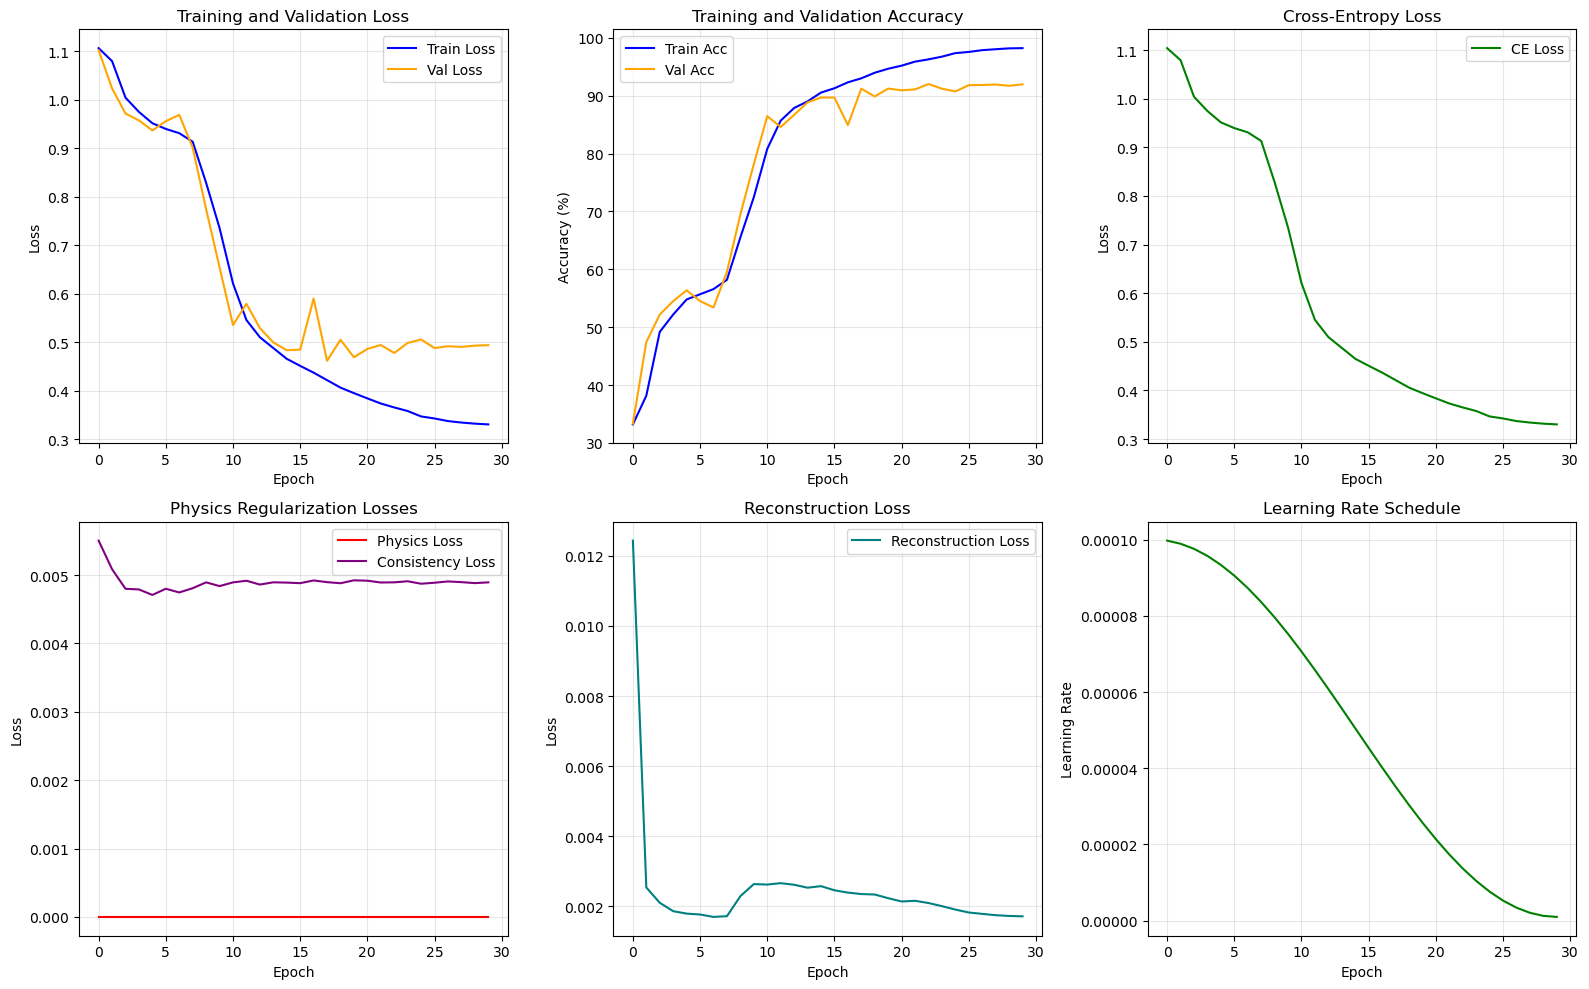

Training history saved to 'training_history.png'


In [18]:
# Cell 15: Plot Training History (updated with reconstruction)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='blue')
ax.plot(history['val_loss'], label='Val Loss', color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot(history['train_acc'], label='Train Acc', color='blue')
ax.plot(history['val_acc'], label='Val Acc', color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# CE Loss
ax = axes[0, 2]
ax.plot(history['train_ce'], label='CE Loss', color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Physics losses
ax = axes[1, 0]
ax.plot(history['train_physics'], label='Physics Loss', color='red')
ax.plot(history['train_consistency'], label='Consistency Loss', color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Physics Regularization Losses')
ax.legend()
ax.grid(True, alpha=0.3)

# Reconstruction loss
ax = axes[1, 1]
ax.plot(history['train_reconstruction'], label='Reconstruction Loss', color='teal')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Reconstruction Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Learning rate
ax = axes[1, 2]
ax.plot(history['lr'], color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history saved to 'training_history.png'")

In [19]:
# Cell 16: Load Best Model and Evaluate on Test Set
# Load best model
model.load_state_dict(best_model_state)
print("Loaded best model weights")

# Evaluate on test set
print("\nEvaluating on Test Set...")
test_metrics = evaluate(model, test_loader, criterion, device)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Loss: {test_metrics['loss']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.2f}%")
print(f"{'='*60}")

# Classification report
class_names = ['No Substructure', 'Sphere', 'Vortex']
print("\nClassification Report:")
print(classification_report(test_metrics['labels'], test_metrics['predictions'], 
                            target_names=class_names))

# Confusion matrix
cm = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])
print("\nConfusion Matrix:")
print(cm)

Loaded best model weights

Evaluating on Test Set...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


TEST SET RESULTS
Test Loss: 0.5745
Test Accuracy: 88.67%

Classification Report:
                 precision    recall  f1-score   support

No Substructure       0.94      0.87      0.90       250
         Sphere       0.87      0.85      0.86       250
         Vortex       0.86      0.94      0.90       250

       accuracy                           0.89       750
      macro avg       0.89      0.89      0.89       750
   weighted avg       0.89      0.89      0.89       750


Confusion Matrix:
[[218  17  15]
 [ 14 213  23]
 [  1  15 234]]


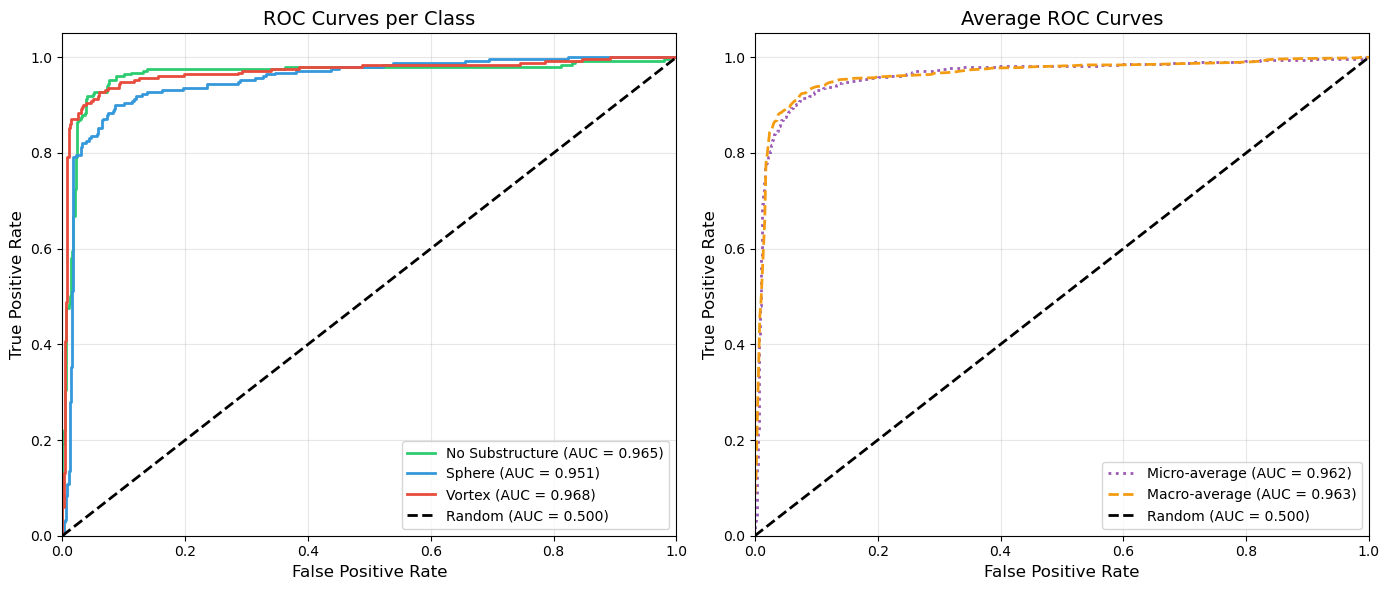


AUC SUMMARY
No Substructure: 0.9653
Sphere: 0.9506
Vortex: 0.9684
--------------------------------------------------
Micro-average: 0.9622
Macro-average: 0.9629


In [20]:
# Cell 17: Plot ROC Curves and AUC
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_true_bin = label_binarize(test_metrics['labels'], classes=[0, 1, 2])
y_probs = test_metrics['probabilities']
n_classes = 3

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Individual class ROC curves
ax = axes[0]
colors = ['#2ecc71', '#3498db', '#e74c3c']
class_names = ['No Substructure', 'Sphere', 'Vortex']

for i, (color, name) in enumerate(zip(colors, class_names)):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f'{name} (AUC = {roc_auc[i]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves per Class', fontsize=14)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

# Micro and Macro average ROC curves
ax = axes[1]
ax.plot(fpr["micro"], tpr["micro"], color='#9b59b6', lw=2, linestyle=':',
        label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')
ax.plot(fpr["macro"], tpr["macro"], color='#f39c12', lw=2, linestyle='--',
        label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Average ROC Curves', fontsize=14)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print AUC summary
print("\n" + "="*50)
print("AUC SUMMARY")
print("="*50)
for i, name in enumerate(class_names):
    print(f"{name}: {roc_auc[i]:.4f}")
print("-"*50)
print(f"Micro-average: {roc_auc['micro']:.4f}")
print(f"Macro-average: {roc_auc['macro']:.4f}")
print("="*50)

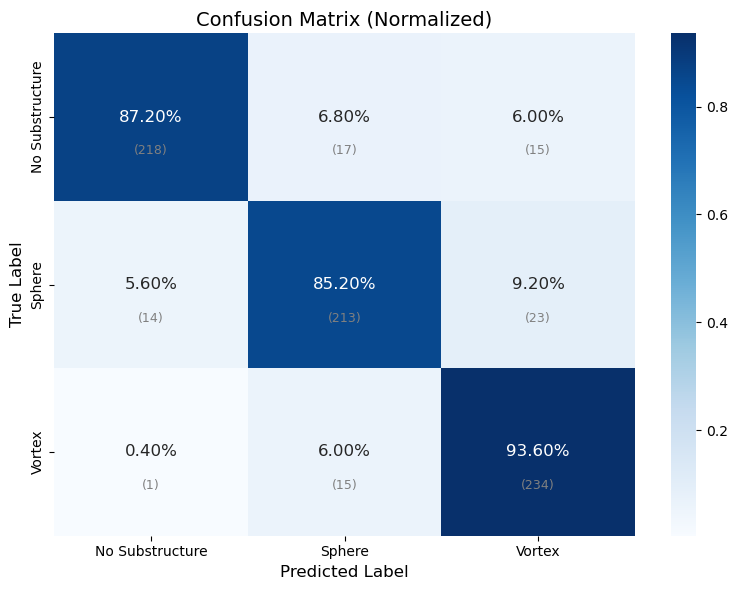

Confusion matrix saved to 'confusion_matrix.png'


In [21]:
# Cell 18: Plot Confusion Matrix Heatmap
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))

class_names = ['No Substructure', 'Sphere', 'Vortex']
cm = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot heatmap
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            annot_kws={'size': 12})

# Add raw counts as text
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j + 0.5, i + 0.7, f'({cm[i, j]})', 
                ha='center', va='center', fontsize=9, color='gray')

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Normalized)', fontsize=14)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to 'confusion_matrix.png'")

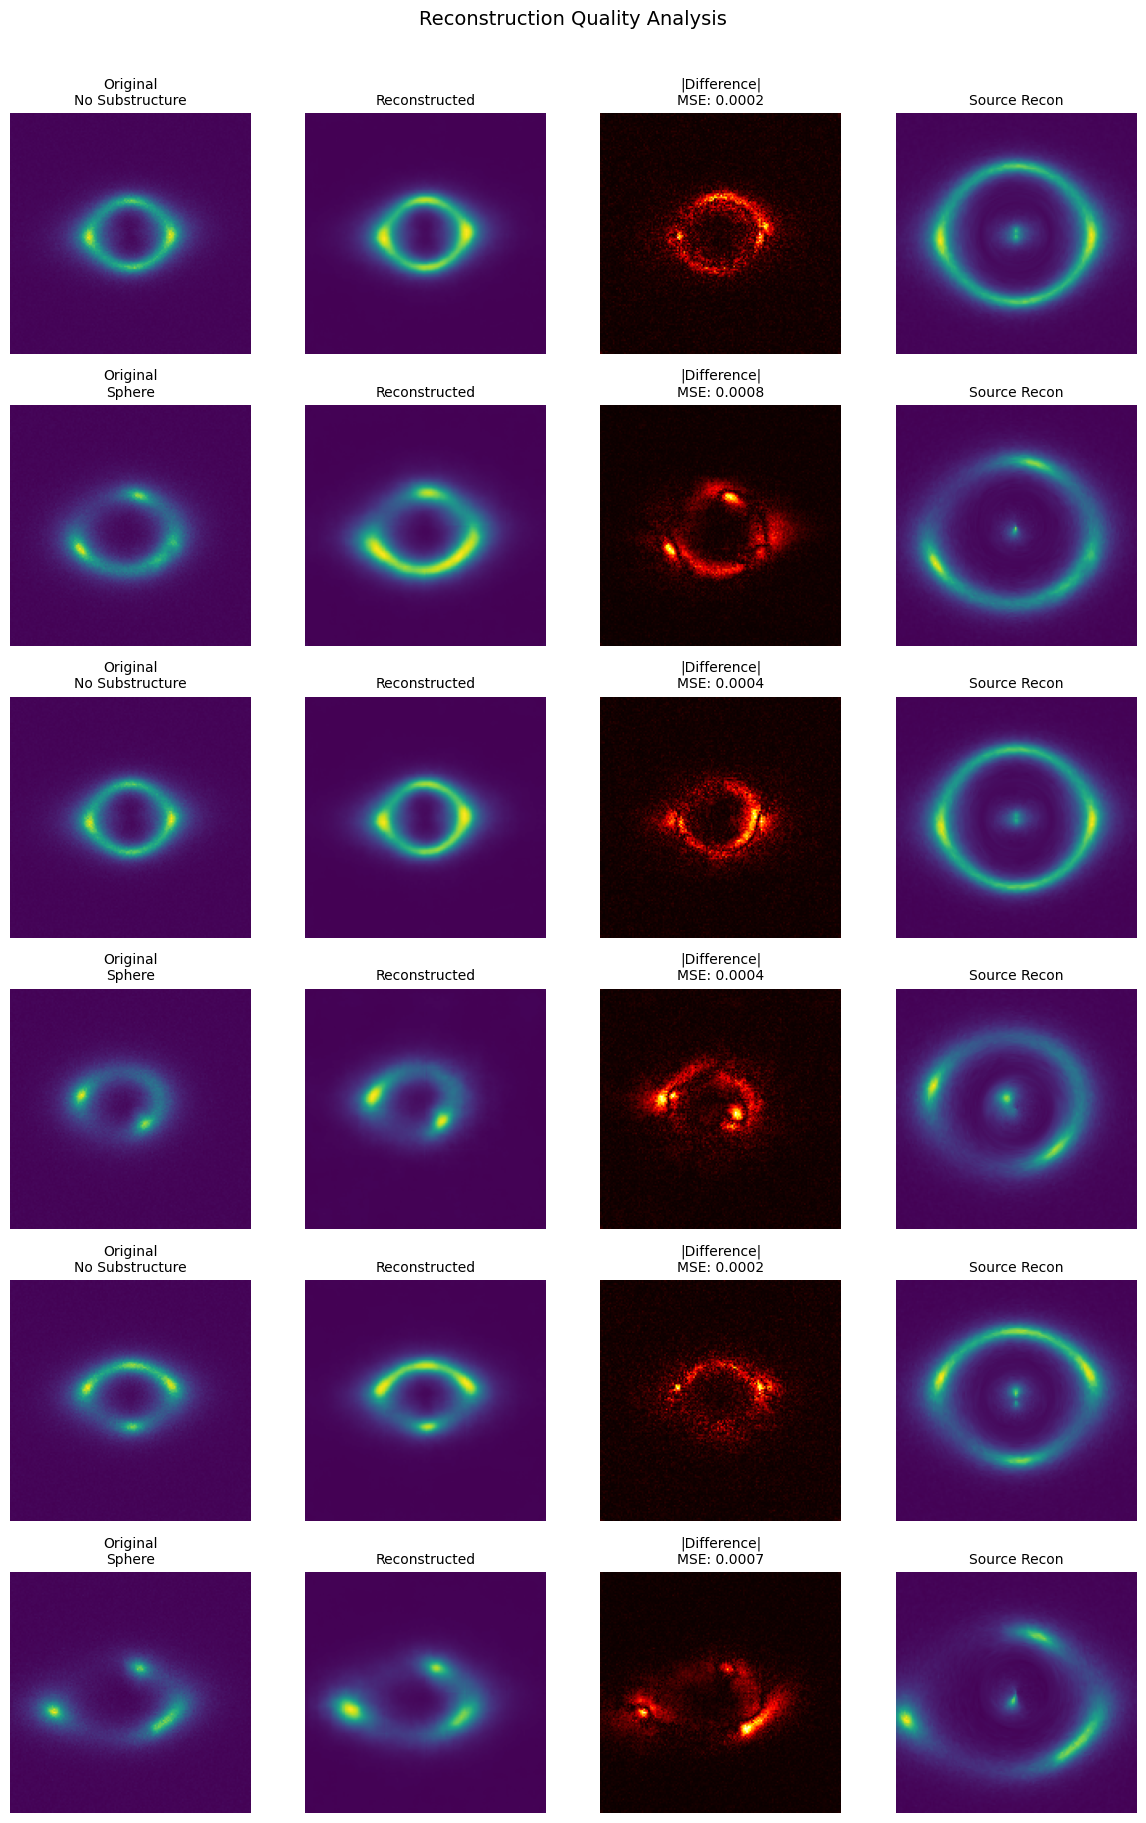

Reconstruction visualization saved to 'reconstruction_quality.png'


In [22]:
# Cell 19.5: Visualize Reconstruction Quality
model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:6].to(device)
sample_labels = sample_labels[:6]

with torch.no_grad():
    outputs = model(sample_images, return_details=True)

reconstructed = outputs['reconstructed'].cpu().numpy()
sources = outputs['source'].cpu().numpy()
original = sample_images.cpu().numpy()

# Plot
fig, axes = plt.subplots(6, 4, figsize=(12, 18))

class_names = ['No Substructure', 'Sphere', 'Vortex']

for i in range(6):
    # Original
    axes[i, 0].imshow(original[i, 0], cmap='viridis')
    axes[i, 0].set_title(f'Original\n{class_names[sample_labels[i]]}', fontsize=10)
    axes[i, 0].axis('off')
    
    # Reconstructed
    axes[i, 1].imshow(reconstructed[i, 0], cmap='viridis')
    axes[i, 1].set_title('Reconstructed', fontsize=10)
    axes[i, 1].axis('off')
    
    # Difference
    diff = np.abs(original[i, 0] - reconstructed[i, 0])
    axes[i, 2].imshow(diff, cmap='hot')
    axes[i, 2].set_title(f'|Difference|\nMSE: {np.mean(diff**2):.4f}', fontsize=10)
    axes[i, 2].axis('off')
    
    # Source
    axes[i, 3].imshow(sources[i, 0], cmap='viridis')
    axes[i, 3].set_title('Source Recon', fontsize=10)
    axes[i, 3].axis('off')

plt.suptitle('Reconstruction Quality Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('reconstruction_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Reconstruction visualization saved to 'reconstruction_quality.png'")

In [23]:
# Cell 20: Save Model
# Save the best model
save_path = 'physics_informed_equivariant_lensnet.pth'

torch.save({
    'model_state_dict': best_model_state,
    'config': config,
    'history': history,
    'best_val_acc': best_val_acc,
    'test_metrics': {
        'accuracy': test_metrics['accuracy'],
        'loss': test_metrics['loss']
    },
    'class_names': class_names,
    'roc_auc': roc_auc
}, save_path)

print(f"Model saved to '{save_path}'")
print(f"\nModel Summary:")
print(f"  - Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"  - Test Accuracy: {test_metrics['accuracy']:.2f}%")
print(f"  - Macro-average AUC: {roc_auc['macro']:.4f}")
print(f"  - Total Parameters: {model.count_parameters():,}")

Model saved to 'physics_informed_equivariant_lensnet.pth'

Model Summary:
  - Best Validation Accuracy: 92.01%
  - Test Accuracy: 88.67%
  - Macro-average AUC: 0.9629
  - Total Parameters: 19,039,651
